# Recon TAN

In [1]:
from deeptan.graph.model import DeepTAN
from deeptan.utils.uni import get_map_location

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



    ____                _________    _   __
   / __ \___  ___  ____/_  __/   |  / | / /
  / / / / _ \/ _ \/ __ \/ / / /| | /  |/ / 
 / /_/ /  __/  __/ /_/ / / / ___ |/ /|  /  
/_____/\___/\___/ .___/_/ /_/  |_/_/ |_/   
               /_/                         




## Read feature names

In [2]:
model_path="/mnt/hdd2/homext/wuch/xn2p/run/logs/bulk_exp_meth_nmic_g_mincv2.0_minmi0.6_0.72_log1p_ft16/seed_42/DeepTAN_20250321024731_NdCYE/best-model-epoch=0015-val_loss=0.0000.ckpt"
model = DeepTAN.load_from_checkpoint(model_path, map_location=get_map_location())
# Freeze the model
model.eval()
model.freeze()

feature_names = model.all_node_names
print(f"{len(feature_names)} features in the model")
print(feature_names)
del model

13461 features in the model
['1:10260958-10261802', '1:10299652-10300562', '1:10365028-10365970', '1:1049505-1050396', '1:1064003-1064914', '1:1080503-1081383', '1:10810482-10811372', '1:10845933-10846851', '1:10859947-10860885', '1:10876176-10876925', '1:10953053-10953976', '1:1102855-1103765', '1:11215644-11216569', '1:11693310-11694195', '1:11830801-11831754', '1:11965892-11966766', '1:12063940-12064843', '1:12264519-12265438', '1:12429337-12430260', '1:12549787-12550720', '1:12961067-12961875', '1:1312721-1313595', '1:1321527-1322294', '1:1355416-1356334', '1:14305397-14306274', '1:148907-149780', '1:1569306-1570304', '1:15880073-15880990', '1:16137287-16138221', '1:16759240-16760200', '1:16817361-16818210', '1:16896612-16897511', '1:17060678-17061590', '1:17097627-17098519', '1:17286545-17287476', '1:172954-173846', '1:17356074-17356991', '1:1740635-1741495', '1:1744232-1745050', '1:17697064-17698020', '1:17934192-17935148', '1:18038889-18039729', '1:18215207-18216132', '1:1823817

## Load correlation matrix

In [3]:
import numpy as np

In [4]:
corr_matrices = np.load("/mnt/hdd2/homext/wuch/xn2p/run/logs/bulk_exp_meth_nmic_g_mincv2.0_minmi0.6_0.72_log1p_ft16/seed_42/predicted_DeepTAN_20250321024731_NdCYE/correlation_matrix.npz")
featfeat_pheno = corr_matrices["corr_matrix"]
featfeat_pheno_weighted = corr_matrices["corr_weighted"]

In [5]:
print(featfeat_pheno.shape)
print(featfeat_pheno)
print(f"\nMinimum correlation: {np.nanmin(featfeat_pheno)}")
print(f"Maximum correlation: {np.nanmax(featfeat_pheno)}")
print(f"Mean correlation: {np.nanmean(featfeat_pheno)}")
print(f"Median correlation: {np.nanmedian(featfeat_pheno)}")

(13461, 13461)
[[-0.01197841 -0.00999079 -0.00973644 ... -0.00866191 -0.00828329
  -0.00879999]
 [-0.00999079  0.01139025 -0.00381392 ... -0.01646383 -0.01583866
  -0.0162809 ]
 [-0.00973644 -0.00381392 -0.0070025  ... -0.00962025 -0.00906356
  -0.00972967]
 ...
 [-0.00866191 -0.01646383 -0.00962025 ... -0.00616233 -0.00570471
  -0.00535611]
 [-0.00828329 -0.01583866 -0.00906356 ... -0.00570471 -0.00526491
  -0.0049308 ]
 [-0.00879999 -0.0162809  -0.00972967 ... -0.00535611 -0.0049308
  -0.00458803]]

Minimum correlation: -0.3723873198032379
Maximum correlation: 0.3586302101612091
Mean correlation: 0.008979512378573418
Median correlation: 0.007908148691058159


In [6]:
# Fill NaN values with 0
featfeat_pheno = np.nan_to_num(featfeat_pheno, nan=0.0)
print(f"\nMinimum correlation: {np.min(featfeat_pheno)}")
print(f"Maximum correlation: {np.max(featfeat_pheno)}")


Minimum correlation: -0.3723873198032379
Maximum correlation: 0.3586302101612091


In [7]:
featfeat_pheno_weighted = np.nan_to_num(featfeat_pheno_weighted, nan=0.0)
print(f"\nMinimum correlation: {np.min(featfeat_pheno_weighted)}")
print(f"Maximum correlation: {np.max(featfeat_pheno_weighted)}")


Minimum correlation: -0.28368866443634033
Maximum correlation: 0.2823566496372223


### Only keep upper triangle of the matrix

In [ ]:
# Create a mask for the upper triangle
# mask = np.triu(np.ones_like(featfeat_pheno, dtype=bool))
# featfeat_pheno = featfeat_pheno[mask]

## Get TOP feature pairs with the highest correlation to phenotype

In [8]:
import polars as pl

In [9]:
sort_ind = np.argsort(featfeat_pheno, axis=None)
print(len(sort_ind))

181198521


In [ ]:
top_high_indices = np.unravel_index(sort_ind[-80000:], featfeat_pheno.shape)
top_low_indices = np.unravel_index(sort_ind[:80000], featfeat_pheno.shape)
featnames_top_high = [(feature_names[i], feature_names[j], featfeat_pheno_weighted[i, j], featfeat_pheno[i, j]) for i, j in zip(top_high_indices[0], top_high_indices[1])]
featnames_top_low = [(feature_names[i], feature_names[j], featfeat_pheno_weighted[i, j], featfeat_pheno[i, j]) for i, j in zip(top_low_indices[0], top_low_indices[1])]

# Convert to DataFrame and save to CSV
top_high_df = pl.DataFrame(featnames_top_high, schema=["Feature1", "Feature2", "Weighted_corr", "Corr"]).sort("Weighted_corr", descending=True)
top_low_df = pl.DataFrame(featnames_top_low, schema=["Feature1", "Feature2", "Weighted_corr", "Corr"]).sort("Weighted_corr", descending=False)
print(top_high_df)
print(top_low_df)

In [ ]:
# # Deduplicate pairs
# top_high_df = top_high_df.unique(subset=["Feature1", "Feature2"], keep="first", maintain_order=True)
# # top_high_df = top_high_df.sort("Correlation", descending=True)
# top_low_df = top_low_df.unique(subset=["Feature1", "Feature2"], keep="first", maintain_order=True)
# # top_low_df = top_low_df.sort("Correlation", descending=False)
# print(top_high_df)
# print(top_low_df)

# Save to CSV
top_high_df.write_csv("top_high_correlations.csv")
top_low_df.write_csv("top_low_correlations.csv")

## Recognize low variant features among samples

In [10]:
featfeat_pheno_abs = np.abs(featfeat_pheno)
sort_ind_abs = np.argsort(featfeat_pheno_abs, axis=None)

In [16]:
print(np.max(featfeat_pheno_abs))
print(np.min(featfeat_pheno_abs))

0.37238732
0.0


In [26]:
top_low_ind_abs = np.unravel_index(sort_ind_abs[2000000:5000000], featfeat_pheno.shape)
featpairs_top_low_abs = [(feature_names[i], feature_names[j], featfeat_pheno_abs[i,j], featfeat_pheno[i, j], featfeat_pheno_weighted[i, j]) for i, j in zip(top_low_ind_abs[0], top_low_ind_abs[1])]
top_low_df_abs = pl.DataFrame(featpairs_top_low_abs, schema=["Feature1", "Feature2", "Corr_abs", "Corr", "Weighted_corr"])

# Filter out the Corr_abs > 0
top_low_df_abs = top_low_df_abs.filter(pl.col("Corr_abs") > 0)
print(top_low_df_abs)

/home/wuch/miniforge3/envs/sc/lib/python3.10/functools.py:889: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)


shape: (2_795_515, 5)
┌────────────────┬─────────────────────┬───────────┬────────────┬───────────────┐
│ Feature1       ┆ Feature2            ┆ Corr_abs  ┆ Corr       ┆ Weighted_corr │
│ ---            ┆ ---                 ┆ ---       ┆ ---        ┆ ---           │
│ str            ┆ str                 ┆ f64       ┆ f64        ┆ f64           │
╞════════════════╪═════════════════════╪═══════════╪════════════╪═══════════════╡
│ AT3G62400      ┆ mCG_AT3G63140       ┆ 6.0940e-9 ┆ -6.0940e-9 ┆ -3.9815e-9    │
│ mCG_AT3G63140  ┆ AT3G62400           ┆ 6.0940e-9 ┆ -6.0940e-9 ┆ -3.9815e-9    │
│ mCG_AT1G07340  ┆ AT2G25160           ┆ 6.2969e-9 ┆ 6.2969e-9  ┆ 3.8046e-9     │
│ AT2G25160      ┆ mCG_AT1G07340       ┆ 6.2969e-9 ┆ 6.2969e-9  ┆ 3.8046e-9     │
│ AT1G05540      ┆ AT3G09870           ┆ 6.5668e-9 ┆ -6.5668e-9 ┆ -4.5652e-9    │
│ …              ┆ …                   ┆ …         ┆ …          ┆ …             │
│ AT5G35935      ┆ AT4G13615           ┆ 0.000278  ┆ -0.000278  ┆ -0.000226 

In [27]:
# Add a new column for the feature relation = Weighted_corr / Corr
top_low_df_abs = top_low_df_abs.with_columns((pl.col("Weighted_corr") / pl.col("Corr")).alias("Feature_relation"))

# Sort
top_low_df_abs = top_low_df_abs.sort(["Feature_relation", "Corr_abs", "Weighted_corr"], descending=[True, False, False])

In [28]:
print(top_low_df_abs)
print(top_low_df_abs["Feature_relation"].min())
print(top_low_df_abs["Feature_relation"].max())

shape: (2_795_515, 6)
┌───────────────┬─────────────────────┬──────────┬───────────┬───────────────┬──────────────────┐
│ Feature1      ┆ Feature2            ┆ Corr_abs ┆ Corr      ┆ Weighted_corr ┆ Feature_relation │
│ ---           ┆ ---                 ┆ ---      ┆ ---       ┆ ---           ┆ ---              │
│ str           ┆ str                 ┆ f64      ┆ f64       ┆ f64           ┆ f64              │
╞═══════════════╪═════════════════════╪══════════╪═══════════╪═══════════════╪══════════════════╡
│ mCG_AT4G16050 ┆ AT5G47120           ┆ 0.000177 ┆ 0.000177  ┆ 0.000157      ┆ 0.890057         │
│ AT5G47120     ┆ mCG_AT4G16050       ┆ 0.000177 ┆ 0.000177  ┆ 0.000157      ┆ 0.890057         │
│ AT5G47120     ┆ AT3G58530           ┆ 0.000159 ┆ 0.000159  ┆ 0.000142      ┆ 0.890001         │
│ AT3G58530     ┆ AT5G47120           ┆ 0.000159 ┆ 0.000159  ┆ 0.000142      ┆ 0.890001         │
│ AT5G47120     ┆ mCHG_AT4G25670      ┆ 0.000069 ┆ 0.000069  ┆ 0.000061      ┆ 0.889976         

In [ ]:
top_low_df_abs.write_csv("top_low_abs_correlations.csv")

In [ ]:
top_low_df_abs[:10000].write_csv("top_low_abs_correlations_head10000.csv")

# Plot the correlation matrix

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

<Figure size 640x480 with 0 Axes>

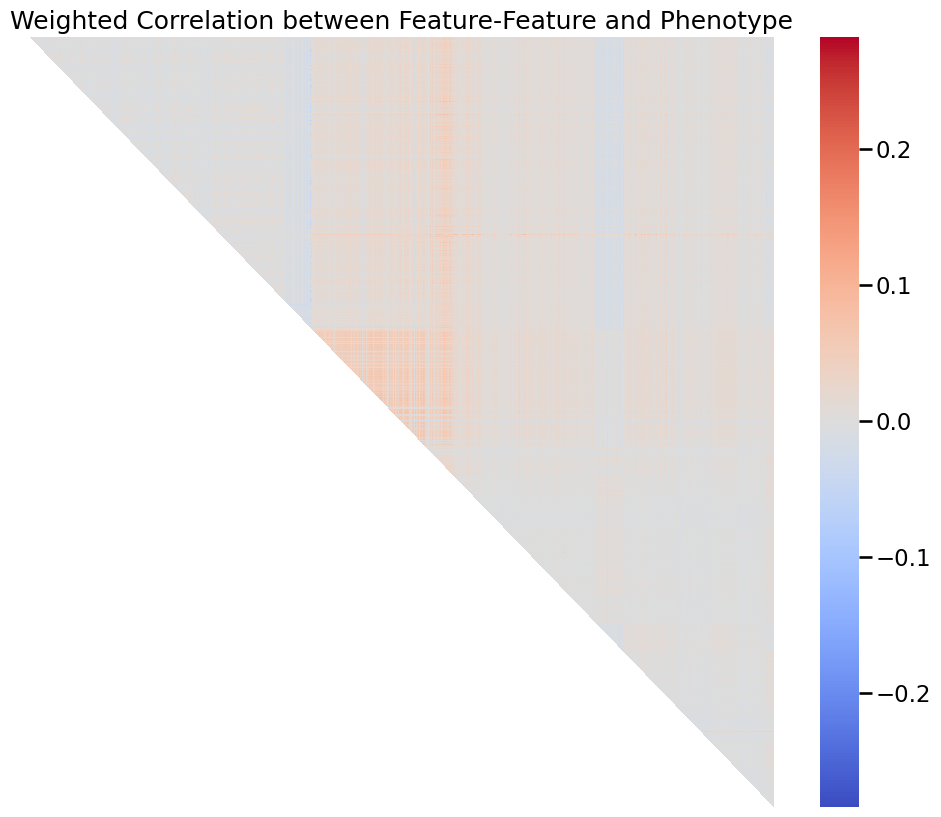

In [37]:
# Try clearing the previous plot if it exists
try:
    plt.clf()
except:
    pass

plt.figure(figsize=(12, 10))
# sns.heatmap(featfeat_pheno, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=feature_names, yticklabels=feature_names)

# Without axis labels for better readability.
# sns.heatmap(featfeat_pheno, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=False, yticklabels=False)

# Clustermap for better visualization of clusters.
# sns.clustermap(featfeat_pheno, cmap='coolwarm')  # , xticklabels=False, yticklabels=False)

# Clustermap with dendrogram, and upper triangle masked, without axis labels.
mask = np.tril(np.ones_like(featfeat_pheno_weighted, dtype=bool))
# sns.clustermap(featfeat_pheno, cmap='coolwarm', mask=mask, xticklabels=False, yticklabels=False)  # , dendrogram_ratio=(.1, .2))  # Adjust dendrogram size if needed. Uncomment to use.
# Failed due to the size of the matrix.

sns.heatmap(featfeat_pheno_weighted, mask=mask, annot=False, fmt=".2f", cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Weighted Correlation between Feature-Feature and Phenotype')
plt.show()